# Visualisation (EDA)

In [150]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import label

In [151]:
df_1 = pd.read_csv("data/fraudTrain.csv", sep=",")
df_2 = pd.read_csv("data/fraudTest.csv", sep=",")
df_2 = df_2[df_2["is_fraud"] != 0]
df = pd.concat([df_1, df_2], axis=0, ignore_index=True)

Augmentation des cas de fraude dans le dataset

In [152]:
df["is_fraud"].value_counts(normalize=True)

is_fraud
0    0.992569
1    0.007431
Name: proportion, dtype: float64

On remarque qu'on a un dataset très déséquilibré

In [153]:
df.sample(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
977435,977435,2020-02-01 05:27:00,3525590521269779,fraud_Schamberger-O'Keefe,grocery_pos,42.02,Scott,Fuller,M,861 Karen Common,...,36.0424,-79.3242,6006,Paramedic,1984-07-20,f3594963d405ea0693ad3862019a41f6,1359696420,36.632303,-80.303926,0
563525,563525,2019-08-27 21:46:37,4736845434667908128,fraud_Schmidt-Larkin,home,157.11,Toni,Gomez,F,062 Carl Dam,...,44.8816,-73.6408,2148,"Surveyor, land/geomatics",1953-05-23,29483299bbb82e50a184c2d97676e69f,1346103997,45.807882,-74.360236,0
1020655,1020655,2020-02-25 21:41:39,4646845581490336108,fraud_Berge-Ullrich,home,15.40,Julia,Bell,F,576 House Crossroad,...,40.7320,-73.1000,4056,Film/video editor,1990-06-25,f15e4dc886fd5ae280ee9ff8f075c6da,1361828499,41.335284,-72.107889,0
1198380,1198380,2020-05-16 05:33:41,4048508450704760,fraud_Emard Inc,gas_transport,36.75,Cheryl,Melton,F,5053 Bell Crescent Apt. 255,...,41.3660,-98.0054,1749,"Surveyor, mining",1973-05-07,2a87bc5716ee7cc2e3c9daad59f5d7dc,1368682421,41.977420,-97.777360,0
773787,773787,2019-11-27 12:49:30,4292902571056973207,"fraud_Hodkiewicz, Prohaska and Paucek",travel,8.61,Jeffrey,Smith,M,135 Joseph Mountains,...,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8843798b88ac75b12398f54d87684b93,1354020570,45.754850,-114.222985,0


In [154]:
df.drop(["merch_lat","merch_long","lat","long",'Unnamed: 0','trans_num','cc_num','last','first','street'], axis=1, inplace=True)

Suppression des colonnes qui vont faire du bruit dans le modèle

<Axes: ylabel='count'>

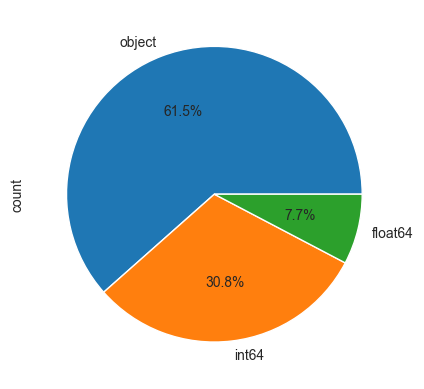

In [155]:
df.dtypes.value_counts().plot.pie(autopct='%1.1f%%')

In [156]:
print(df.duplicated().sum().sum())

0


Pas de valeur dupliqué

In [157]:
df.describe(include="all")

,trans_date_trans_time,merchant,category,amt,gender,city,state,zip,city_pop,job,dob,unix_time,is_fraud
count,1298820,1298820,1298820,1.298820e+06,1298820,1298820,1298820,1.298820e+06,1.298820e+06,1298820,1298820,1.298820e+06,1.298820e+06
unique,1276936,693,14,NaN,2,906,51,NaN,NaN,497,984,NaN,NaN
top,2019-04-22 16:02:01,fraud_Kilback LLC,gas_transport,NaN,F,Birmingham,TX,NaN,NaN,Film/video editor,1977-03-23,NaN,NaN
freq,4,4418,131813,NaN,711027,5642,94989,NaN,NaN,9787,5651,NaN,NaN
mean,NaN,NaN,NaN,7.110743e+01,NaN,NaN,NaN,4.879912e+04,8.878432e+04,NaN,NaN,1.349294e+09,7.430591e-03
std,NaN,NaN,NaN,1.620471e+02,NaN,NaN,NaN,2.689293e+04,3.018400e+05,NaN,NaN,1.289102e+07,8.588005e-02
min,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,1.257000e+03,2.300000e+01,NaN,NaN,1.325376e+09,0.000000e+00
25%,NaN,NaN,NaN,9.660000e+00,NaN,NaN,NaN,2.623700e+04,7.430000e+02,NaN,NaN,1.338761e+09,0.000000e+00
50%,NaN,NaN,NaN,4.758000e+01,NaN,NaN,NaN,4.817400e+04,2.456000e+03,NaN,NaN,1.349296e+09,0.000000e+00
75%,NaN,NaN,NaN,8.331000e+01,NaN,NaN,NaN,7.201100e+04,2.032800e+04,NaN,NaN,1.359494e+09,0.000000e+00


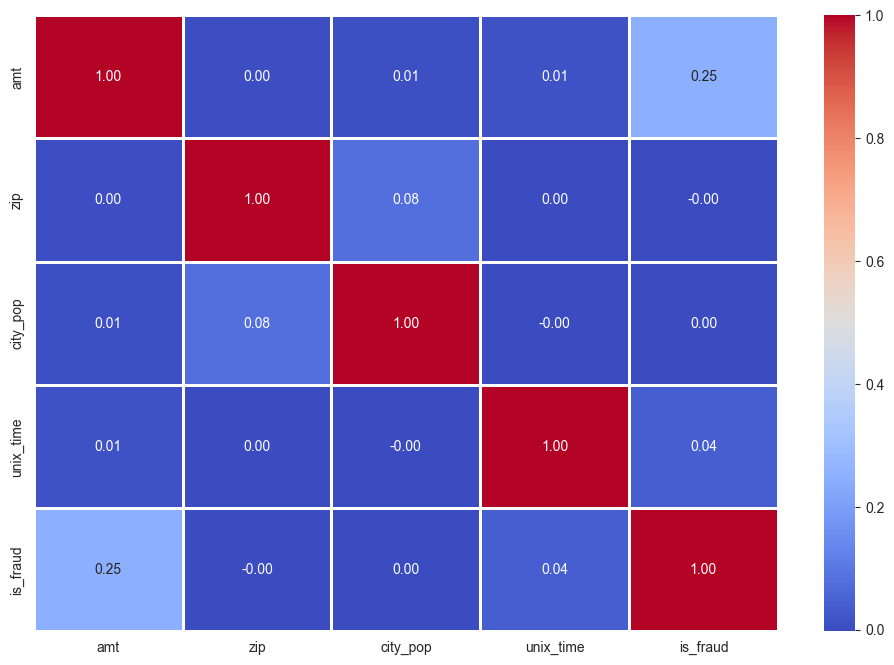

In [158]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
#kot = corr[(corr !=1.000) & ((corr >=0.4) | (corr <=(-0.2)))]
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=1,
            )
plt.show()

Pas de corrélation entre nos données quantitative

# Preprocessing

In [159]:
# Prétraitement
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder,OrdinalEncoder,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [160]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df['age_at_transaction'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
df['age_at_transaction'] = df['age_at_transaction'].round(0).astype(int)
df['age_at_transaction']

0          31
1          41
2          57
3          52
4          33
           ..
1298815    62
1298816    62
1298817    62
1298818    62
1298819    62
Name: age_at_transaction, Length: 1298820, dtype: int64

On peut déduire l'age de la personne qui a déclaré la fraude avec sa date de naissance et le timestamp du moment de la fraude.

In [161]:
"""# S'assurer que la colonne est bien au format datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extraire les composants standards
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek # 0=Lundi, 6=Dimanche
df['month'] = df['trans_date_trans_time'].dt.month
df['is_night'] = df['hour'].apply(lambda x: 1 if (x <= 6 or x >= 22) else 0) # Binaire nuit/jour

# On crée les composantes Sinus et Cosinus pour l'heure (cycle de 24)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# On crée les composantes Sinus et Cosinus pour le jour (cycle de 7)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Supprimer la colonne originale qui pose problème
df = df.drop(columns=['trans_date_trans_time','hour', 'day_of_week','dob'])"""
df = df.drop(columns=['trans_date_trans_time','dob'])

In [162]:
df_sav = df.copy()

In [163]:
 #"hour_sin", "hour_cos", "day_sin", "day_cos"
numeric_features = ["amt", "zip", "city_pop", "age_at_transaction",'unix_time']
categorical_features_non_ord = ["state", "city","gender","category","merchant","job"]

In [164]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_non_ord_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinay", LabelEncoder())
])

# 1. Définition propre du ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # Pour les colonnes numériques
        ('num', StandardScaler(), numeric_features),
        # Pour les colonnes catégorielles (utilise OrdinalEncoder pour le non-supervisé)
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features_non_ord)
    ],
    remainder='drop' # On ignore les colonnes non listées (comme 'zip' si elle pose problème)
)

In [165]:
df.drop('is_fraud', axis=1, inplace=True)

In [166]:
# Modèles de Machine Learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor,IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, auc,roc_auc_score,precision_recall_curve
from sklearn.cluster import KMeans

In [167]:
model_IsoForest = IsolationForest(
    n_estimators=100,
    contamination=0.01, # On cible tes 1%
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

# 1. Pipeline uniquement pour le nettoyage
preprocessor_pipe = Pipeline([
    ('preprocessor', preprocessor)
])

# 2. On transforme les données
X_transformed = preprocessor_pipe.fit_transform(df)

In [168]:
model_IsoForest.fit(X_transformed)
y_pred = model_IsoForest.predict(X_transformed)

In [169]:
df_final = pd.DataFrame(y_pred, columns=['predictions'])

In [170]:
df_final.value_counts()

predictions
 1             1285831
-1               12989
Name: count, dtype: int64

In [171]:
df_final['predictions'] = df_final['predictions'].map({-1:1,1:0})

              precision    recall  f1-score   support

           0       0.99      0.99      0.99   1289169
           1       0.15      0.20      0.17      9651

    accuracy                           0.99   1298820
   macro avg       0.57      0.60      0.58   1298820
weighted avg       0.99      0.99      0.99   1298820



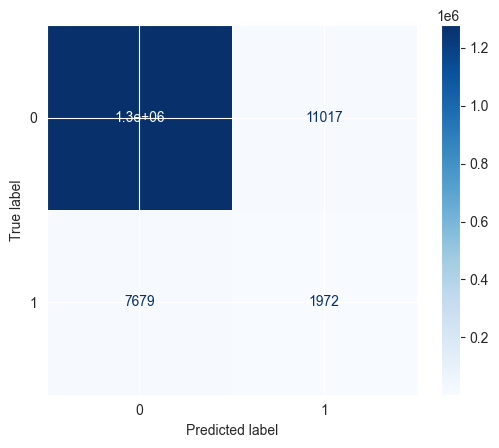

In [172]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Afficher les métriques clés (Précision, Rappel, F1-Score)
print(classification_report(df_sav['is_fraud'], df_final['predictions']))

# Visualiser la matrice de confusion de manière pro
ConfusionMatrixDisplay.from_predictions(df_sav['is_fraud'], df_final['predictions'],cmap='Blues')

              precision    recall  f1-score   support

           0       0.99      0.99      0.99   1289169
           1       0.08      0.11      0.09      9651

    accuracy                           0.98   1298820
   macro avg       0.54      0.55      0.54   1298820
weighted avg       0.99      0.98      0.99   1298820


<sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1dfaa252190>
<Figure size 640x480 with 2 Axes>